# Hábitos digitales y bienestar estudiantil

## Primera Entrega — Ciencia de Datos

### Objetivo

Analizar exploratoriamente la relación entre los hábitos digitales, los hábitos de vida y el bienestar de estudiantes.

El análisis busca identificar patrones y asociaciones entre el uso de redes sociales, herramientas de inteligencia artificial, horas de sueño, actividad física y los indicadores de salud mental y física.

### Fuente de datos

Dataset obtenido desde Kaggle:

AI & Social Media Impact: Student Health & Grades

https://www.kaggle.com/datasets/srisyra02/ai-and-social-media-impact-student-health-and-grades




### Motivación

El análisis surge del interés por comprender cómo los hábitos digitales y de vida se relacionan con el bienestar de los estudiantes.

Identificar estos patrones permite obtener una primera visión sobre posibles factores asociados al bienestar y generar preguntas para análisis posteriores.

### Público objetivo

El análisis está orientado a personas responsables de instituciones educativas y otros actores interesados en comprender los hábitos digitales y de vida de los estudiantes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [27]:
# Descarga del dataset desde Kaggle

!pip install -q kagglehub

import kagglehub
import os
import shutil

ruta_kaggle = kagglehub.dataset_download(
    "srisyra02/ai-and-social-media-impact-student-health-and-grades"
)

print("Dataset descargado en:")
print(ruta_kaggle)

print("\nArchivos disponibles:")
print(os.listdir(ruta_kaggle))

Using Colab cache for faster access to the 'ai-and-social-media-impact-student-health-and-grades' dataset.
Dataset descargado en:
/kaggle/input/ai-and-social-media-impact-student-health-and-grades

Archivos disponibles:
['AI_SocialMedia_Student_Dataset.csv']


In [28]:
# Guardar el dataset descargado como archivo CSV local

import shutil

ruta_csv = "/kaggle/input/ai-and-social-media-impact-student-health-and-grades/AI_SocialMedia_Student_Dataset.csv"

shutil.copy(
    ruta_csv,
    "dataset_estudiantes_local.csv"
)

print("Archivo guardado correctamente como: dataset_estudiantes_local.csv")

Archivo guardado correctamente como: dataset_estudiantes_local.csv


In [29]:
# Cargar el dataset desde el archivo local descargado desde Kaggle

df = pd.read_csv("dataset_estudiantes_local.csv")

df.head()



,Student_ID,Age,Gender,Education_Level,Daily_Social_Media_Hours,Daily_AI_Tool_Usage_Hours,Sleep_Hours,Physical_Activity_Hours,Mental_Health_Score,Physical_Health_Score
0,STU_00001,19,Male,College,5.32,1.21,7.30,1.41,74.06,98.90
1,STU_00002,16,Non-binary,High School,5.21,3.89,7.81,2.48,76.13,89.94
2,STU_00003,25,Male,University,3.61,2.65,6.34,0.06,65.01,76.75
3,STU_00004,23,Male,University,2.93,1.43,6.12,1.37,74.67,87.38
4,STU_00005,20,Non-binary,College,6.52,1.64,5.23,1.14,67.74,88.04


### Carga de datos

El dataset fue descargado desde Kaggle mediante Python y guardado localmente en formato CSV para realizar el análisis exploratorio.

In [5]:
df.shape


(16000, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Student_ID                 16000 non-null  object 
 1   Age                        16000 non-null  int64  
 2   Gender                     16000 non-null  object 
 3   Education_Level            16000 non-null  object 
 4   Daily_Social_Media_Hours   16000 non-null  float64
 5   Daily_AI_Tool_Usage_Hours  16000 non-null  float64
 6   Sleep_Hours                16000 non-null  float64
 7   Physical_Activity_Hours    16000 non-null  float64
 8   Mental_Health_Score        16000 non-null  float64
 9   Physical_Health_Score      16000 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 1.2+ MB


In [7]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Education_Level,0
Daily_Social_Media_Hours,0
Daily_AI_Tool_Usage_Hours,0
Sleep_Hours,0
Physical_Activity_Hours,0
Mental_Health_Score,0
Physical_Health_Score,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Student_ID"].duplicated().sum()

np.int64(0)

In [10]:
df.describe().round(2)

,Age,Daily_Social_Media_Hours,Daily_AI_Tool_Usage_Hours,Sleep_Hours,Physical_Activity_Hours,Mental_Health_Score,Physical_Health_Score
count,16000.00,16000.00,16000.00,16000.00,16000.00,16000.00,16000.00
mean,19.04,4.54,2.59,6.55,1.25,72.49,88.02
std,3.77,2.40,1.68,1.27,1.04,9.24,9.69
min,13.00,0.00,0.00,2.00,0.00,32.56,48.03
25%,16.00,2.84,1.31,5.68,0.31,66.76,81.52
50%,19.00,4.50,2.52,6.54,1.13,73.75,89.46
75%,22.00,6.18,3.75,7.41,1.96,79.55,97.17
max,25.00,14.00,9.50,11.15,5.00,91.76,99.98


In [26]:
df.to_csv("dataset_estudiantes_local.csv", index=False)

## Pregunta 1: Redes sociales y sueño

**¿Existe una relación entre la cantidad de horas diarias de uso de redes sociales y las horas de sueño de los estudiantes?**

### Hipótesis

Se espera observar una relación negativa: a mayor cantidad de horas de uso de redes sociales, menor cantidad de horas de sueño.

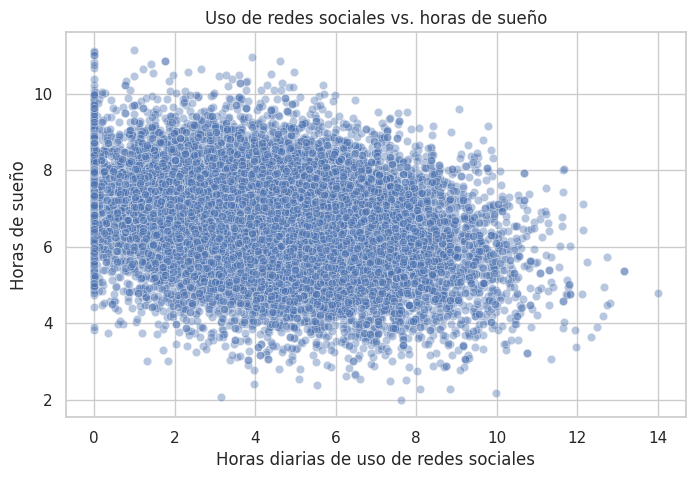

In [11]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Daily_Social_Media_Hours",
    y="Sleep_Hours",
    alpha=0.4
)

plt.title("Uso de redes sociales vs. horas de sueño")
plt.xlabel("Horas diarias de uso de redes sociales")
plt.ylabel("Horas de sueño")
plt.show()

### Interpretación

Se observa una relación negativa entre el uso diario de redes sociales y las horas de sueño: a medida que aumenta el uso de redes, las horas de sueño tienden a disminuir.

Sin embargo, la relación es débil, por lo que el uso de redes sociales por sí solo no permite explicar las diferencias observadas en las horas de sueño.


## Pregunta 2: Uso digital y bienestar

**¿Existe una relación entre la intensidad de uso digital y el nivel de bienestar de los estudiantes?**

### Hipótesis

Se espera observar una relación negativa: a mayor intensidad de uso digital, menor nivel de bienestar.

In [13]:
df["Digital_Use_Index"] = (
    (df["Daily_Social_Media_Hours"] / 14) * 50 +
    (df["Daily_AI_Tool_Usage_Hours"] / 9.5) * 50
)

df["Wellbeing_Index"] = (
    (df["Mental_Health_Score"] / 91.76) * 40 +
    (df["Physical_Health_Score"] / 99.98) * 30 +
    (df["Sleep_Hours"] / 11.15) * 20 +
    (df["Physical_Activity_Hours"] / 5) * 10
)

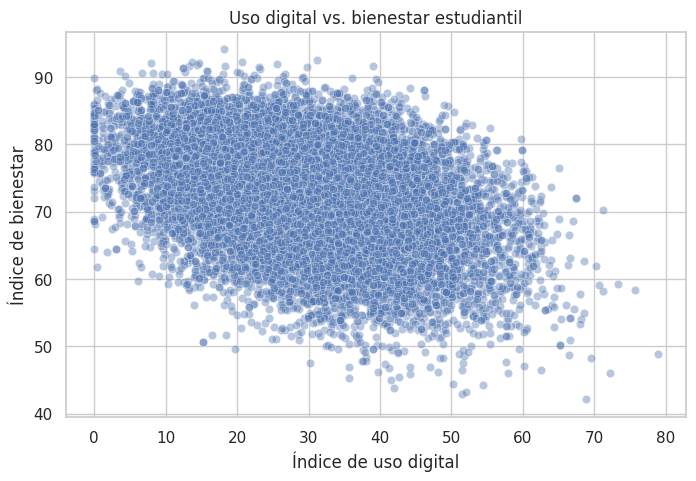

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Digital_Use_Index",
    y="Wellbeing_Index",
    alpha=0.4
)

plt.title("Uso digital vs. bienestar estudiantil")
plt.xlabel("Índice de uso digital")
plt.ylabel("Índice de bienestar")
plt.show()

### Interpretación

Se observa una relación negativa entre el índice de uso digital y el índice de bienestar: a medida que aumenta la intensidad de uso digital, el bienestar tiende a disminuir.

Sin embargo, los datos presentan una dispersión considerable, por lo que el uso digital por sí solo no explica completamente las diferencias observadas en el bienestar.

In [15]:
correlacion = df["Digital_Use_Index"].corr(df["Wellbeing_Index"])

print(f"Coeficiente de correlación: {correlacion:.3f}")
print(f"R²: {correlacion**2:.3f}")

Coeficiente de correlación: -0.395
R²: 0.156


**Resultado estadístico:** correlación = -0,395 | R² = 0,156

## Pregunta 3: Actividad física y bienestar

**¿Existe una relación entre las horas diarias de actividad física y el nivel de bienestar de los estudiantes?**

### Hipótesis

Se espera observar una relación positiva: a mayor cantidad de horas de actividad física, mayor nivel de bienestar.

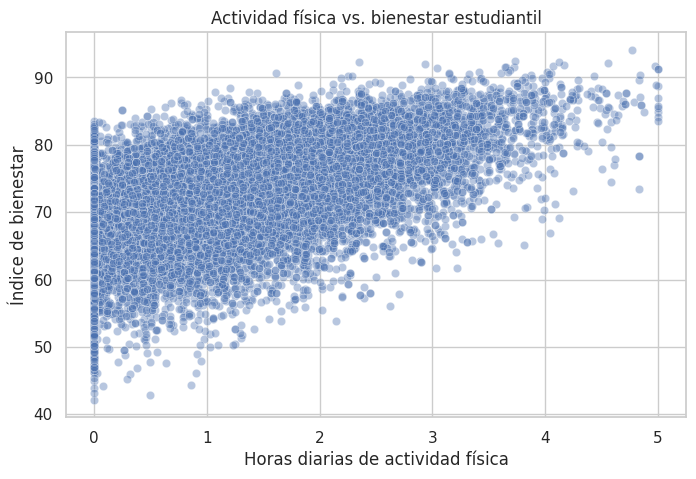

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Physical_Activity_Hours",
    y="Wellbeing_Index",
    alpha=0.4
)

plt.title("Actividad física vs. bienestar estudiantil")
plt.xlabel("Horas diarias de actividad física")
plt.ylabel("Índice de bienestar")
plt.show()

### Interpretación

Se observa una relación positiva entre las horas de actividad física y el índice de bienestar: los estudiantes que registran más actividad física tienden a presentar mayores niveles de bienestar.

La correlación de 0,572 indica una asociación positiva moderada. El R² de 0,327 muestra que existe una relación relevante entre ambas variables, aunque también intervienen otros factores.

In [17]:
correlacion = df["Physical_Activity_Hours"].corr(df["Wellbeing_Index"])

print(f"Coeficiente de correlación: {correlacion:.3f}")
print(f"R²: {correlacion**2:.3f}")

Coeficiente de correlación: 0.572
R²: 0.327


**Resultado estadístico:** correlación = 0,572 | R² = 0,327

## Pregunta 4: Uso de IA y bienestar

**¿Existen diferencias en el nivel de bienestar promedio según el nivel de uso de herramientas de inteligencia artificial?**

### Hipótesis

Se espera observar diferencias en el bienestar promedio entre los estudiantes con bajo, medio y alto uso de herramientas de IA.

In [18]:
df["AI_Use_Level"] = pd.cut(
    df["Daily_AI_Tool_Usage_Hours"],
    bins=[-np.inf, 2, 4, np.inf],
    labels=["Bajo", "Medio", "Alto"],
    right=False
)

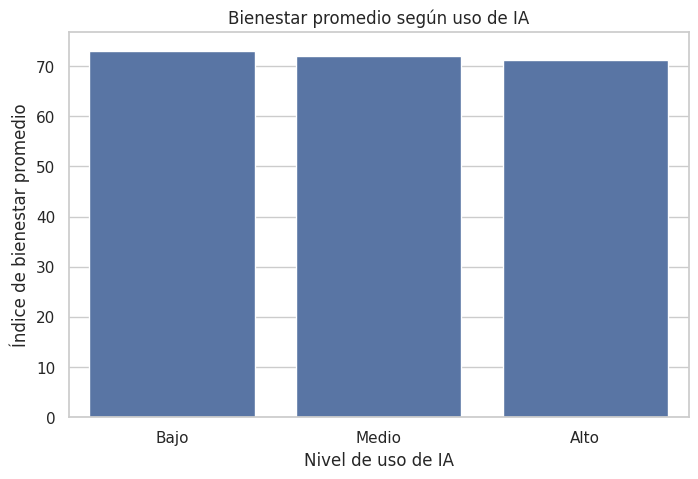

In [19]:
promedio_bienestar_ia = (
    df.groupby("AI_Use_Level", observed=True)["Wellbeing_Index"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=promedio_bienestar_ia,
    x="AI_Use_Level",
    y="Wellbeing_Index"
)

plt.title("Bienestar promedio según uso de IA")
plt.xlabel("Nivel de uso de IA")
plt.ylabel("Índice de bienestar promedio")
plt.show()

In [20]:
promedio_bienestar_ia

,AI_Use_Level,Wellbeing_Index
0,Bajo,73.076700
1,Medio,71.975631
2,Alto,71.243906


### Interpretación

El bienestar promedio disminuye a medida que aumenta el nivel de uso de herramientas de IA: pasa de 73,08 en el grupo de uso bajo a 71,24 en el grupo de uso alto.

La diferencia entre los grupos es moderada, por lo que estos resultados muestran una asociación y no permiten afirmar que el uso de IA sea la causa de las diferencias observadas en el bienestar.

**Bienestar promedio:** Bajo = 73,08 | Medio = 71,98 | Alto = 71,24

## Pregunta 5: Uso de IA según nivel educativo

**¿Existen diferencias en el nivel de uso de herramientas de IA según el nivel educativo de los estudiantes?**

### Hipótesis

Se espera encontrar diferencias en la distribución de los niveles de uso de IA entre los distintos niveles educativos.

In [21]:
tabla_ia_educacion = pd.crosstab(
    df["Education_Level"],
    df["AI_Use_Level"],
    normalize="index"
) * 100

tabla_ia_educacion.round(2)

AI_Use_Level,Bajo,Medio,Alto
Education_Level,,,
College,38.36,40.92,20.72
High School,38.91,40.65,20.43
University,38.63,40.42,20.95


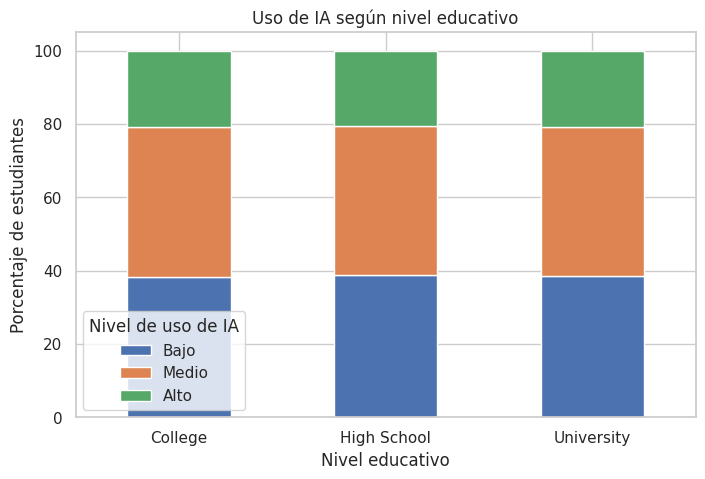

In [22]:
tabla_ia_educacion.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Uso de IA según nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Porcentaje de estudiantes")
plt.xticks(rotation=0)
plt.legend(title="Nivel de uso de IA")
plt.show()

### Interpretación

La distribución de los niveles de uso de herramientas de IA es muy similar entre College, High School y University.

El nivel medio concentra aproximadamente el 40% de los estudiantes en los tres grupos, mientras que el nivel bajo representa cerca del 39% y el nivel alto alrededor del 21%.

No se observan diferencias marcadas en el uso de IA según el nivel educativo.

**Distribución aproximada:** Bajo ≈ 39% | Medio ≈ 41% | Alto ≈ 21%

## Análisis exploratorio de datos

### Distribución de edades

La edad permite observar cómo se distribuye la población estudiantil analizada.

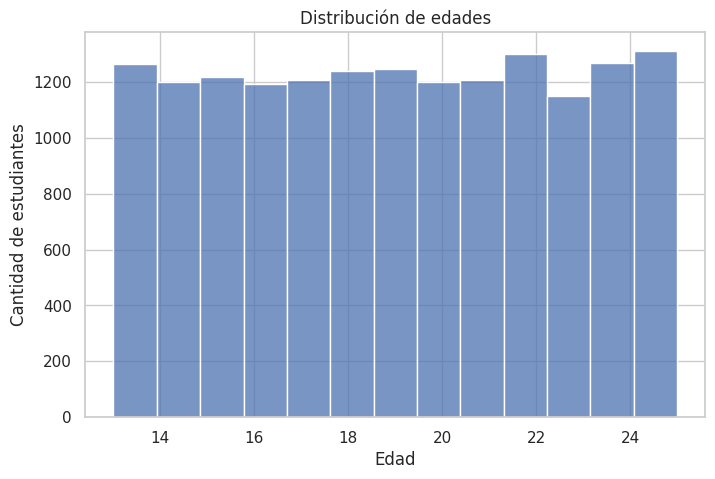

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Age",
    bins=13
)

plt.title("Distribución de edades")
plt.xlabel("Edad")
plt.ylabel("Cantidad de estudiantes")
plt.show()

### Interpretación

La muestra presenta estudiantes de entre 13 y 25 años. La distribución de edades es relativamente uniforme, sin una concentración marcada en un rango específico.

### Distribución del uso de redes sociales

Se analiza la cantidad de horas diarias que los estudiantes destinan al uso de redes sociales.

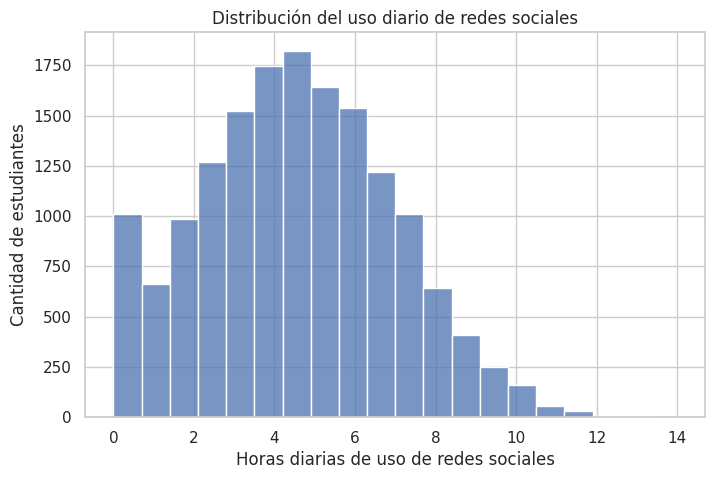

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Daily_Social_Media_Hours",
    bins=20
)

plt.title("Distribución del uso diario de redes sociales")
plt.xlabel("Horas diarias de uso de redes sociales")
plt.ylabel("Cantidad de estudiantes")
plt.show()

### Interpretación

El uso diario de redes sociales se concentra principalmente entre 3 y 6 horas. A partir de ese rango, la cantidad de estudiantes disminuye progresivamente, mientras que los valores superiores a 10 horas representan una proporción menor de la muestra.

# Principales insights

A partir del análisis exploratorio realizado, se identificaron los siguientes patrones:

- El uso de redes sociales presenta una asociación negativa con las horas de sueño. La relación es débil (R² = 0,0885).

- El índice de uso digital presenta una asociación negativa con el índice de bienestar (correlación = -0,395; R² = 0,156).

- La actividad física presenta una asociación positiva con el bienestar (correlación = 0,572; R² = 0,327), siendo una de las relaciones más marcadas observadas.

- El bienestar promedio disminuye entre los grupos de bajo, medio y alto uso de herramientas de IA: 73,08; 71,98 y 71,24 respectivamente.

- La distribución del uso de IA es similar entre College, High School y University. Aproximadamente el 39% presenta un nivel bajo, el 41% un nivel medio y el 21% un nivel alto.

## Consideraciones

Los resultados corresponden a un análisis exploratorio de los datos. Las asociaciones observadas no permiten establecer relaciones de causalidad.

# Conclusión

El análisis exploratorio permitió identificar asociaciones entre los hábitos digitales, los hábitos de vida y el bienestar de los estudiantes.

Entre los principales resultados se destaca la relación positiva entre actividad física y bienestar, mientras que el uso de redes sociales y la intensidad de uso digital presentan asociaciones negativas con el sueño y el bienestar.

El análisis también muestra que el nivel educativo presenta una distribución similar en cuanto al uso de herramientas de IA.

Estos resultados permiten identificar patrones iniciales que pueden ser profundizados en etapas posteriores mediante la incorporación de nuevas variables y análisis más detallados.

# Fuente de datos

Dataset: **AI & Social Media Impact: Student Health & Grades**

Fuente: Kaggle

https://www.kaggle.com/datasets/srisyra02/ai-and-social-media-impact-student-health-and-grades

El análisis se realizó sobre el archivo CSV original descargado desde la fuente.